# Pairwise scatter plots for top-5 overall MOGA-Phonons solutions

This notebook loads `dataframe000013.pkl` and `dataframe000014.pkl`, aggregates them, keeps the **top 5 overall** solutions for each independent dataset and each `(mass, lattice parameter)` pair, and generates individual pairwise scatter plots.

Two complete sets of scatter plots are generated:

1. Scatter plots colored by lattice parameter.
2. Scatter plots colored by mass.

The notebook saves each pairwise plot individually as both PDF and PNG.


In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = "retina"

DATA_DIR = Path("./dataframes/")  # update if needed

DATAFRAME_FILES = {
    "dataframe000013": DATA_DIR / "dataframe000013.pkl",
    "dataframe000014": DATA_DIR / "dataframe000014.pkl",
    "dataframe000015": DATA_DIR / "dataframe000015.pkl",
    "dataframe000016": DATA_DIR / "dataframe000016.pkl",
}

OUTPUT_DIR = Path("pairwise_scatter_top5_overall")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 5
RANK_BY = "fitness_norm"

SAVE_FORMATS = ("pdf", "png")
DPI = 300

FIGSIZE = (5.6, 4.6)
MARKER_SIZE = 42
MARKER_ALPHA = 0.82
EDGE_WIDTH = 0.25


In [2]:
def find_first_existing(candidates, columns):
    for col in candidates:
        if col in columns:
            return col
    return None


def load_dataframe(path, dataset_label):
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path}. Update DATA_DIR or DATAFRAME_FILES at the top of the notebook."
        )
    df = pd.read_pickle(path).copy()
    df["dataset"] = dataset_label
    return df


def safe_token(name):
    return (
        str(name).replace("\\", "").replace("$", "").replace("{", "").replace("}", "")
        .replace("^", "").replace("_", "").replace(" ", "_").replace("/", "_")
    )


def display_label(col):
    label_map = {
        "mass": r"$m$ (amu)", "m": r"$m$ (amu)",
        "a_val": r"$a$ ($\AA$)", "alat": r"$a$ ($\AA$)",
        "a_latt": r"$a$ ($\AA$)", "lattice_parameter": r"$a$ ($\AA$)",
        "alpha0": r"$\alpha_0$ (eV/$\AA^2$)", "alpha_0": r"$\alpha_0$ (eV/$\AA^2$)",
        "alpha1": r"$\alpha_1$ (N/m)", "alpha_1": r"$\alpha_1$ (N/m)",
        "beta1": r"$\beta_1$ (N/m)", "beta_1": r"$\beta_1$ (N/m)",
        "alpha2": r"$\alpha_2$ (N/m)", "alpha_2": r"$\alpha_2$ (N/m)",
        "beta2": r"$\beta_2$ (N/m)", "beta_2": r"$\beta_2$ (N/m)",
        "fitness1": r"$f_1$", "f1": r"$f_1$",
        "fitness2": r"$f_2$", "f2": r"$f_2$",
        "fitness3": r"$f_3$", "f3": r"$f_3$",
        "fitness_norm": r"$f_{\mathrm{norm}}$", "fnorm": r"$f_{\mathrm{norm}}$",
        "min_frequency": r"$\omega_{\min}$ (THz)", "min_freq": r"$\omega_{\min}$ (THz)",
        "max_frequency": r"$\omega_{\max}$ (THz)", "max_freq": r"$\omega_{\max}$ (THz)",
        "num_imaginary": r"$N_-$", "n_imaginary": r"$N_-$",
        "dataset": "Dataset",
    }
    return label_map.get(col, col)


def choose_canonical_columns(columns):
    preferred_groups = [
        ["mass", "m"],
        ["a_val", "alat", "a_latt", "lattice_parameter"],
        ["alpha0", "alpha_0"],
        ["alpha1", "alpha_1"],
        ["beta1", "beta_1"],
        ["alpha2", "alpha_2"],
        ["beta2", "beta_2"],
        ["fitness1", "f1"],
        ["fitness2", "f2"],
        ["fitness3", "f3"],
        ["fitness_norm", "fnorm"],
        ["min_frequency", "min_freq"],
        ["max_frequency", "max_freq"],
        ["num_imaginary", "n_imaginary"],
    ]
    selected = []
    for group in preferred_groups:
        col = find_first_existing(group, columns)
        if col is not None:
            selected.append(col)
    return selected


def save_figure(fig, stem, output_dir, formats=SAVE_FORMATS):
    output_dir.mkdir(parents=True, exist_ok=True)
    saved = []
    for ext in formats:
        outpath = output_dir / f"{stem}.{ext}"
        fig.savefig(outpath, dpi=DPI, bbox_inches="tight")
        saved.append(outpath)
    return saved


def apply_publication_axes(ax):
    ax.tick_params(
        axis="both", which="both", direction="in",
        top=True, right=True, labelsize=12, length=5, width=1.1,
    )
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.1)


In [3]:
frames = []
for label, path in DATAFRAME_FILES.items():
    tmp = load_dataframe(path, label)
    print(f"{label}: {tmp.shape[0]:,} rows, {tmp.shape[1]:,} columns")
    frames.append(tmp)

df_all = pd.concat(frames, ignore_index=True)
print(f"\nAggregated dataframe before filtering: {df_all.shape[0]:,} rows, {df_all.shape[1]:,} columns")
df_all.head()


dataframe000013: 105,000 rows, 35 columns
dataframe000014: 105,000 rows, 35 columns
dataframe000015: 105,000 rows, 35 columns
dataframe000016: 105,000 rows, 35 columns

Aggregated dataframe before filtering: 420,000 rows, 35 columns


,simulation,generation,solution_index,rank,source,timestamp,mass,a_val,system_size,alpha0,...,gamma_frequencies,distances,qpoints,frequencies,frequency_vector,simulation_path,generation_dir,solution_dir,band_yaml_path,dataset
0,simulation000588,1,5,0,population,2026-05-22T19:33:42.238245,50.0,2.0,5,5.607430,...,"[0.8275024, 0.8275024, 0.8275024]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.8275024, 0.8275024, 0.8275024], [0.8291954...","[0.8275024, 0.8275024, 0.8275024, 0.8291954, 0...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
1,simulation000588,1,92,1,population,2026-05-22T19:33:42.238245,50.0,2.0,5,6.189523,...,"[1.562392, 1.562392, 1.562392]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[1.562392, 1.562392, 1.562392], [1.563087, 1....","[1.562392, 1.562392, 1.562392, 1.563087, 1.563...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
2,simulation000588,1,44,2,population,2026-05-22T19:33:42.238245,50.0,2.0,5,3.931578,...,"[-1.0034583, -1.0034583, -1.0034583]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.0034583, -1.0034583, -1.0034583], [-1.002...","[-1.0034583, -1.0034583, -1.0034583, -1.002285...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
3,simulation000588,1,155,3,population,2026-05-22T19:33:42.238245,50.0,2.0,5,6.349680,...,"[1.0862614, 1.0862614, 1.0862614]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[1.0862614, 1.0862614, 1.0862614], [1.0880687...","[1.0862614, 1.0862614, 1.0862614, 1.0880687, 1...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
4,simulation000588,1,125,4,population,2026-05-22T19:33:42.238245,50.0,2.0,5,8.587408,...,"[-1.2866693, -1.2866693, -1.2866693]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.2866693, -1.2866693, -1.2866693], [-1.284...","[-1.2866693, -1.2866693, -1.2866693, -1.284834...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013


In [4]:
mass_col = find_first_existing(["mass", "m"], df_all.columns)
alat_col = find_first_existing(["a_val", "alat", "a_latt", "lattice_parameter"], df_all.columns)
rank_col = find_first_existing([RANK_BY, "fitness_norm", "fnorm"], df_all.columns)

if mass_col is None:
    raise ValueError("Could not find a mass column. Expected one of: mass, m")
if alat_col is None:
    raise ValueError("Could not find a lattice-parameter column. Expected one of: a_val, alat, a_latt, lattice_parameter")
if rank_col is None:
    raise ValueError("Could not find a ranking column. Expected fitness_norm or fnorm.")

print(f"Detected mass column: {mass_col}")
print(f"Detected lattice-parameter column: {alat_col}")
print(f"Detected ranking column: {rank_col}")


Detected mass column: mass
Detected lattice-parameter column: a_val
Detected ranking column: fitness_norm


In [5]:
df_top = (
    df_all.sort_values(rank_col, ascending=False)
    .groupby(["dataset", mass_col, alat_col], group_keys=False)
    .head(TOP_K)
    .copy()
)

print(f"Filtered dataframe after top-{TOP_K}-overall selection: {df_top.shape[0]:,} rows")

selection_summary = (
    df_top.groupby(["dataset", mass_col, alat_col])
    .size()
    .reset_index(name="n_selected")
)

display(selection_summary.head(20))
print(selection_summary["n_selected"].describe())


Filtered dataframe after top-5-overall selection: 840 rows


,dataset,mass,a_val,n_selected
0,dataframe000013,50.0,2.0,5
1,dataframe000013,50.0,2.2,5
2,dataframe000013,50.0,2.4,5
3,dataframe000013,50.0,2.6,5
4,dataframe000013,50.0,2.8,5
5,dataframe000013,50.0,3.0,5
6,dataframe000013,50.0,3.2,5
7,dataframe000013,60.0,2.0,5
8,dataframe000013,60.0,2.2,5
9,dataframe000013,60.0,2.4,5


count    168.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0
Name: n_selected, dtype: float64


In [6]:
variable_cols = choose_canonical_columns(df_top.columns)

plot_df = df_top[["dataset"] + variable_cols].copy()
for col in variable_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

before = plot_df.shape[0]
plot_df = plot_df.dropna(axis=0, how="any").copy()
after = plot_df.shape[0]

print(f"Variables included ({len(variable_cols)}):")
for c in variable_cols:
    print(f"  {c} -> {display_label(c)}")

print(f"\nRows available for plotting: {after:,} / {before:,}")
plot_df.head()


Variables included (14):
  mass -> $m$ (amu)
  a_val -> $a$ ($\AA$)
  alpha0 -> $\alpha_0$ (eV/$\AA^2$)
  alpha1 -> $\alpha_1$ (N/m)
  beta1 -> $\beta_1$ (N/m)
  alpha2 -> $\alpha_2$ (N/m)
  beta2 -> $\beta_2$ (N/m)
  fitness1 -> $f_1$
  fitness2 -> $f_2$
  fitness3 -> $f_3$
  fitness_norm -> $f_{\mathrm{norm}}$
  min_frequency -> $\omega_{\min}$ (THz)
  max_frequency -> $\omega_{\max}$ (THz)
  num_imaginary -> $N_-$

Rows available for plotting: 840 / 840


,dataset,mass,a_val,alpha0,alpha1,beta1,alpha2,beta2,fitness1,fitness2,fitness3,fitness_norm,min_frequency,max_frequency,num_imaginary
214621,dataframe000015,50.0,2.2,5.173158,-0.321338,-0.017194,0.000162,-0.650614,1.0,0.999673,1.0,1.731862,0.039549,6.166276,0
214938,dataframe000015,50.0,2.2,5.173158,-0.321338,0.025992,0.000162,-0.650614,1.0,0.999673,1.0,1.731862,0.039549,6.168211,0
214926,dataframe000015,50.0,2.2,5.173158,-0.321338,0.025992,0.000162,-0.650614,1.0,0.999673,1.0,1.731862,0.039549,6.168211,0
214927,dataframe000015,50.0,2.2,5.173158,-0.321338,0.631618,0.000162,-0.650614,1.0,0.999673,1.0,1.731862,-0.560340,7.196012,62
214928,dataframe000015,50.0,2.2,5.173158,-0.321338,0.025992,0.000162,-0.650614,1.0,0.999673,1.0,1.731862,0.039549,6.168211,0


In [7]:
def plot_pairwise_scatter(
    data, x_col, y_col, color_col, output_dir,
    cmap="viridis", include_dataset_markers=True,
):
    fig, ax = plt.subplots(figsize=FIGSIZE)

    c_all = data[color_col].astype(float)

    markers = {
        "dataframe000013": "o",
        "dataframe000014": "s",
    }

    scatter_ref = None

    if include_dataset_markers and "dataset" in data.columns:
        for dataset_label, sub in data.groupby("dataset"):
            marker = markers.get(dataset_label, "o")
            sc = ax.scatter(
                sub[x_col].astype(float),
                sub[y_col].astype(float),
                c=sub[color_col].astype(float),
                cmap=cmap,
                s=MARKER_SIZE,
                alpha=MARKER_ALPHA,
                edgecolors="black",
                linewidths=EDGE_WIDTH,
                marker=marker,
                vmin=c_all.min(),
                vmax=c_all.max(),
                label=dataset_label,
            )
            scatter_ref = sc
        ax.legend(frameon=False, fontsize=9, loc="best")
    else:
        scatter_ref = ax.scatter(
            data[x_col].astype(float),
            data[y_col].astype(float),
            c=c_all,
            cmap=cmap,
            s=MARKER_SIZE,
            alpha=MARKER_ALPHA,
            edgecolors="black",
            linewidths=EDGE_WIDTH,
        )

    ax.set_xlabel(display_label(x_col), fontsize=14)
    ax.set_ylabel(display_label(y_col), fontsize=14)
    ax.set_title(f"{display_label(y_col)} vs. {display_label(x_col)}", fontsize=15, pad=10)

    apply_publication_axes(ax)

    cbar = fig.colorbar(scatter_ref, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(display_label(color_col), fontsize=13)
    cbar.ax.tick_params(labelsize=11)

    fig.tight_layout()

    stem = f"{safe_token(y_col)}_vs_{safe_token(x_col)}_colored_by_{safe_token(color_col)}"
    saved = save_figure(fig, stem, output_dir)

    plt.close(fig)
    return saved


In [8]:
pairs = list(combinations(variable_cols, 2))
print(f"Number of variable pairs: {len(pairs)}")

output_dir_a = OUTPUT_DIR / "colored_by_lattice_parameter"
all_saved_a = []

for x_col, y_col in pairs:
    saved = plot_pairwise_scatter(
        plot_df,
        x_col=x_col,
        y_col=y_col,
        color_col=alat_col,
        output_dir=output_dir_a,
        cmap="viridis",
        include_dataset_markers=True,
    )
    all_saved_a.extend(saved)

print(f"Saved {len(all_saved_a)} files to {output_dir_a}")


Number of variable pairs: 91
Saved 182 files to pairwise_scatter_top5_overall/colored_by_lattice_parameter


In [9]:
output_dir_m = OUTPUT_DIR / "colored_by_mass"
all_saved_m = []

for x_col, y_col in pairs:
    saved = plot_pairwise_scatter(
        plot_df,
        x_col=x_col,
        y_col=y_col,
        color_col=mass_col,
        output_dir=output_dir_m,
        cmap="plasma",
        include_dataset_markers=True,
    )
    all_saved_m.extend(saved)

print(f"Saved {len(all_saved_m)} files to {output_dir_m}")


Saved 182 files to pairwise_scatter_top5_overall/colored_by_mass


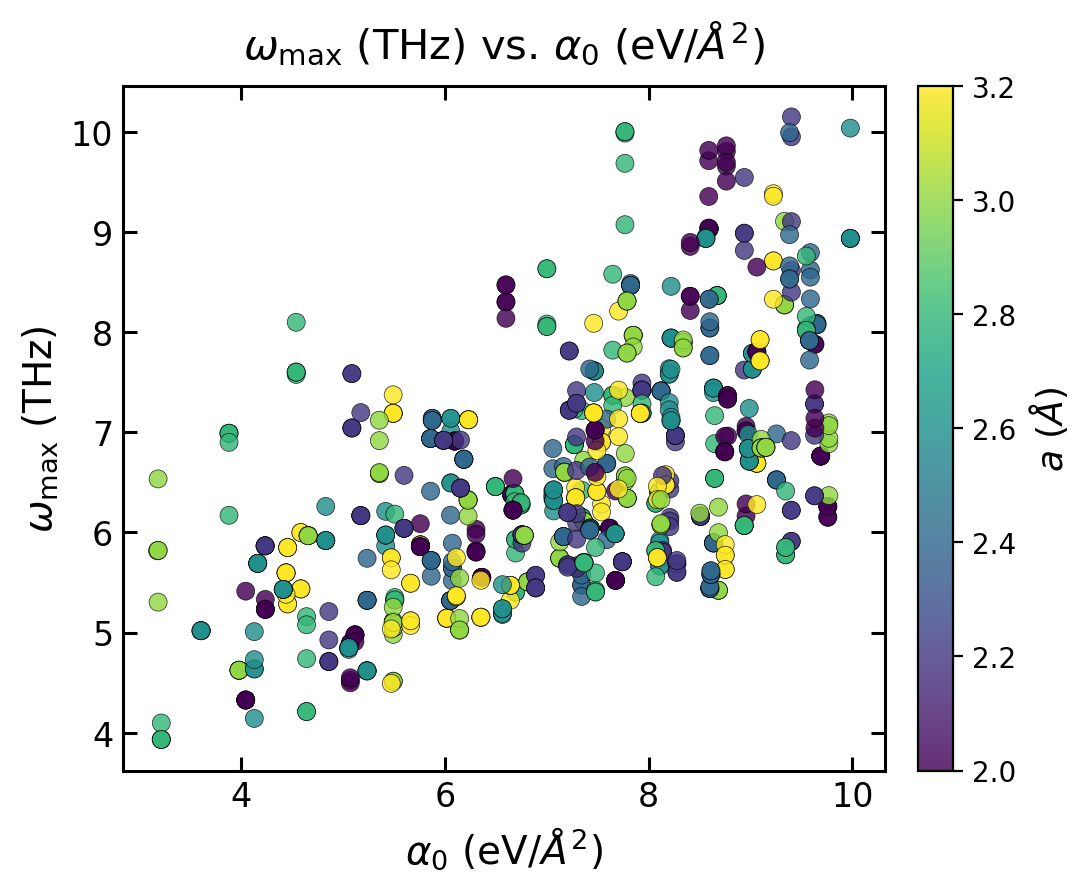

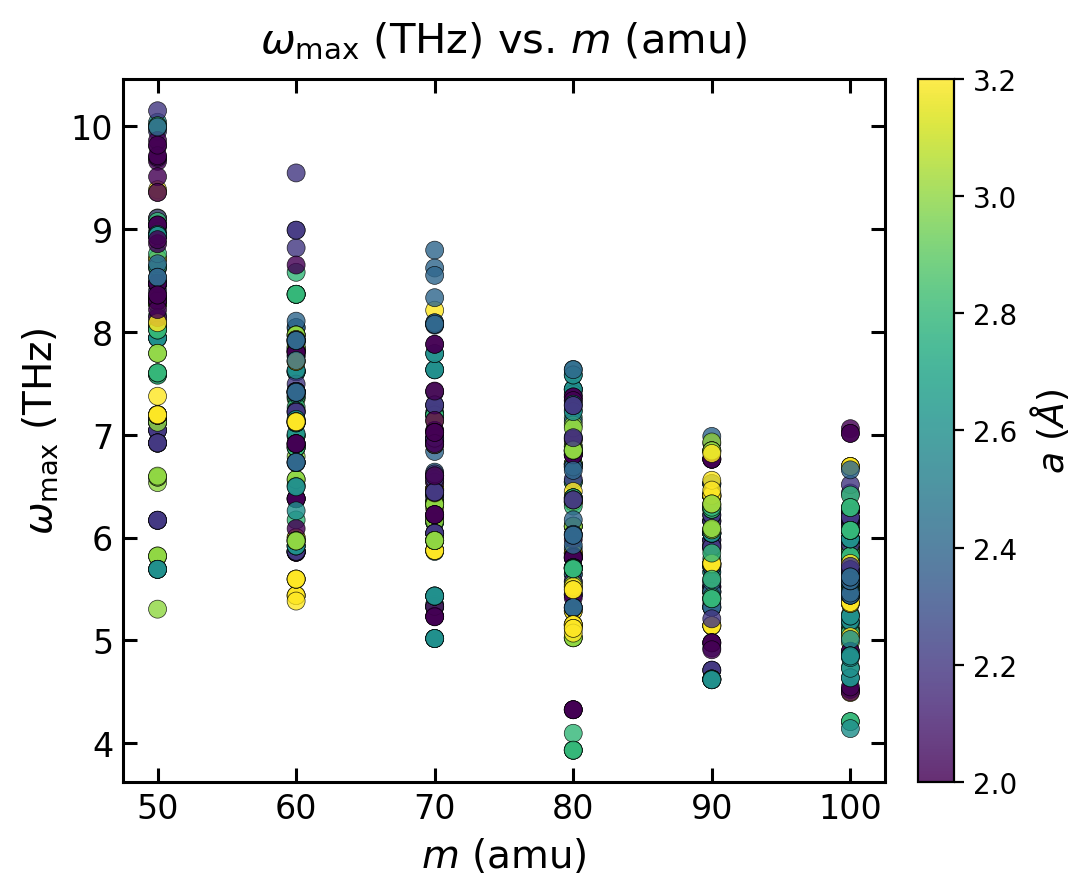

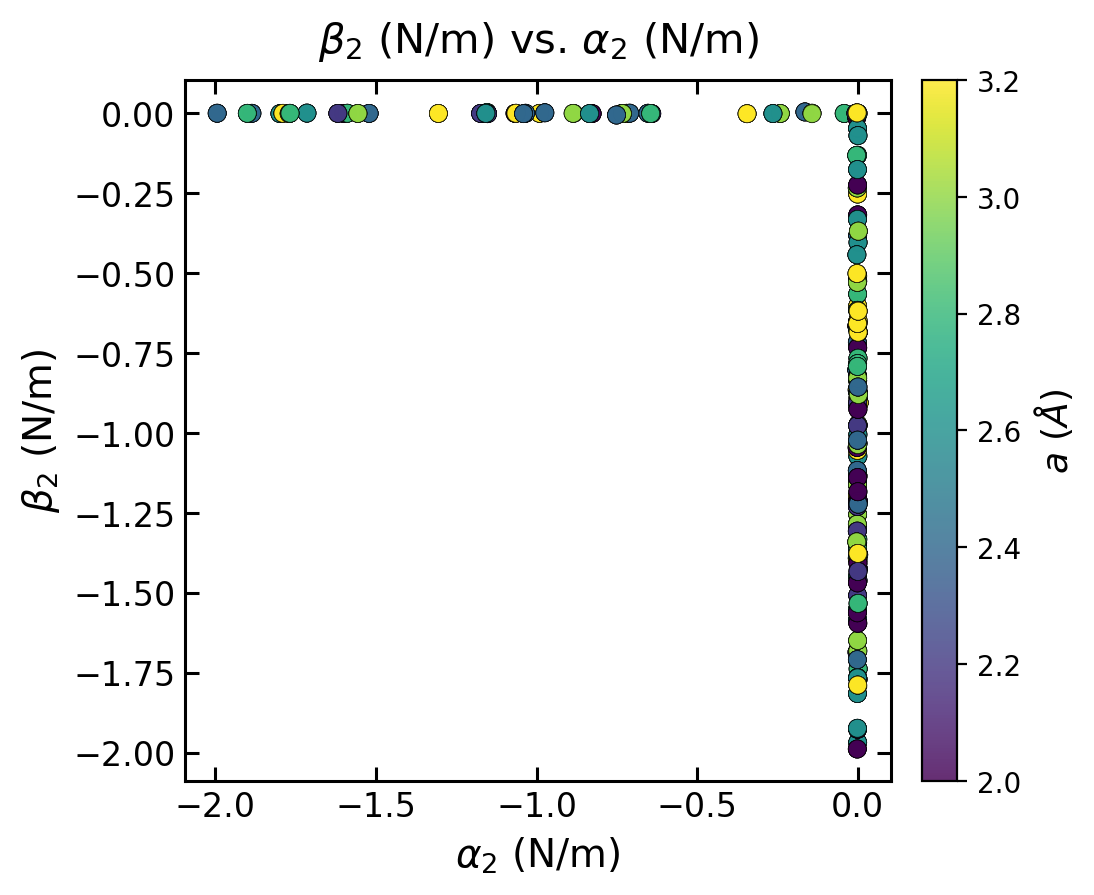

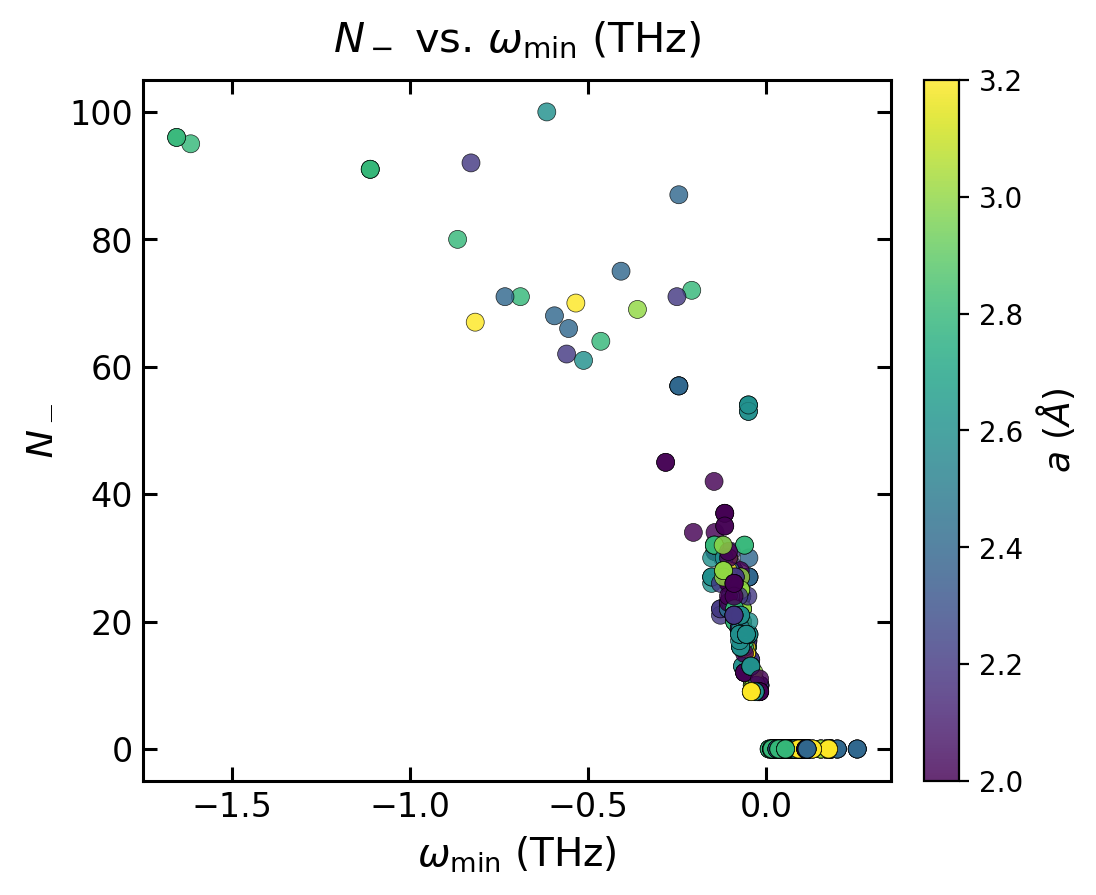

In [10]:
# Preview a few useful plots in the notebook.
EXAMPLE_PAIRS = [
    ("alpha0", "max_frequency"),
    ("alpha_0", "max_frequency"),
    ("mass", "max_frequency"),
    ("m", "max_frequency"),
    ("alpha2", "beta2"),
    ("alpha_2", "beta_2"),
    ("min_frequency", "num_imaginary"),
    ("min_freq", "n_imaginary"),
]

valid_examples = []
for x_col, y_col in EXAMPLE_PAIRS:
    if x_col in plot_df.columns and y_col in plot_df.columns:
        valid_examples.append((x_col, y_col))

for x_col, y_col in valid_examples[:4]:
    fig, ax = plt.subplots(figsize=FIGSIZE)

    sc = ax.scatter(
        plot_df[x_col],
        plot_df[y_col],
        c=plot_df[alat_col],
        cmap="viridis",
        s=MARKER_SIZE,
        alpha=MARKER_ALPHA,
        edgecolors="black",
        linewidths=EDGE_WIDTH,
    )

    ax.set_xlabel(display_label(x_col), fontsize=14)
    ax.set_ylabel(display_label(y_col), fontsize=14)
    ax.set_title(f"{display_label(y_col)} vs. {display_label(x_col)}", fontsize=15, pad=10)

    apply_publication_axes(ax)

    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(display_label(alat_col), fontsize=13)

    fig.tight_layout()
    plt.show()


## Output

The notebook writes two folders:

```text
pairwise_scatter_top5_overall/colored_by_lattice_parameter/
pairwise_scatter_top5_overall/colored_by_mass/
```

Each folder contains one PDF and one PNG for every pair of selected variables.

Dataset identity is shown through marker shape:

- circles: `dataframe000013`
- squares: `dataframe000014`

Color is reserved for either lattice parameter or mass, depending on the output folder.
